In [1]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

# Cargar el dataset de dígitos (similar a MNIST pero 8x8)
print("Cargando dataset de dígitos...")
digits = load_digits()
X = digits.data
y = digits.target.astype(str)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train unique values: {np.unique(y_train)}")


Cargando dataset de dígitos...
X_train shape: (1437, 64)
X_test shape: (360, 64)
y_train unique values: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


### `Comparación` de Clasificadores Binarios

Vamos a evaluar cuatro clasificadores binarios ('5' vs 'no 5') en el conjunto de prueba (test set) del dataset MNIST. Los clasificadores a comparar son: `SGDClassifier`, `KNeighborsClassifier`, `LogisticRegression` y `RandomForestClassifier`.

In [4]:
# Importar los clasificadores necesarios
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Preparar los datos de entrenamiento binarios (5 vs no 5)
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

classifiers = {
    "SGDClassifier": SGDClassifier(random_state=42),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(random_state=42)
}

results = {}

for name, clf in classifiers.items():
    print(f"Entrenando {name}...")
    if name == "KNeighborsClassifier":
        # KNeighborsClassifier puede ser lento con muchos datos, se entrena con un subconjunto o se ajustan parámetros
        # Para este ejemplo, entrenaremos con el conjunto completo para una evaluación justa.
        # Sin embargo, si el entrenamiento es muy lento, se podría considerar X_train[:10000]
        clf.fit(X_train, y_train_5)
    elif name == "LogisticRegression":
        # LogisticRegression necesita una convergencia de iteraciones y solver
        clf.fit(X_train, y_train_5)
    else:
        clf.fit(X_train, y_train_5)

    print(f"Evaluando {name}...")
    y_pred = clf.predict(X_test)

    # Obtener scores de decisión o probabilidades para la curva ROC
    if hasattr(clf, "decision_function"):
        y_scores = clf.decision_function(X_test)
    elif hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test)[:, 1]
    else:
        y_scores = None # No se puede calcular ROC si no hay scores o probas

    precision = precision_score(y_test_5, y_pred)
    recall = recall_score(y_test_5, y_pred)
    f1 = f1_score(y_test_5, y_pred)
    auc = roc_auc_score(y_test_5, y_scores) if y_scores is not None else 'N/A'

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC": auc,
        "y_scores": y_scores # Guardar scores para la curva ROC
    }

    print(f"{name} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, AUC: {auc:.4f}")

# Imprimir resultados en una tabla
print("\n--- Resultados de los Clasificadores en el Test Set ---")
print("| Clasificador           | Precision | Recall    | F1-Score  | AUC       |")
print("|------------------------|-----------|-----------|-----------|-----------|")
for name, metrics in results.items():
    print(f"| {name:<22} | {metrics['Precision']:.7f} | {metrics['Recall']:.7f} | {metrics['F1-Score']:.7f} | {metrics['AUC']:.7f} |")


Entrenando SGDClassifier...
Evaluando SGDClassifier...
SGDClassifier - Precision: 0.9773, Recall: 0.9149, F1-Score: 0.9451, AUC: 0.9995
Entrenando KNeighborsClassifier...
Evaluando KNeighborsClassifier...
KNeighborsClassifier - Precision: 0.9783, Recall: 0.9574, F1-Score: 0.9677, AUC: 0.9998
Entrenando LogisticRegression...
Evaluando LogisticRegression...
LogisticRegression - Precision: 0.9375, Recall: 0.9574, F1-Score: 0.9474, AUC: 0.9988
Entrenando RandomForestClassifier...
Evaluando RandomForestClassifier...
RandomForestClassifier - Precision: 1.0000, Recall: 0.8936, F1-Score: 0.9438, AUC: 0.9996

--- Resultados de los Clasificadores en el Test Set ---
| Clasificador           | Precision | Recall    | F1-Score  | AUC       |
|------------------------|-----------|-----------|-----------|-----------|
| SGDClassifier          | 0.9772727 | 0.9148936 | 0.9450549 | 0.9995242 |
| KNeighborsClassifier   | 0.9782609 | 0.9574468 | 0.9677419 | 0.9998301 |
| LogisticRegression     | 0.9375000

### Curva ROC para los Clasificadores

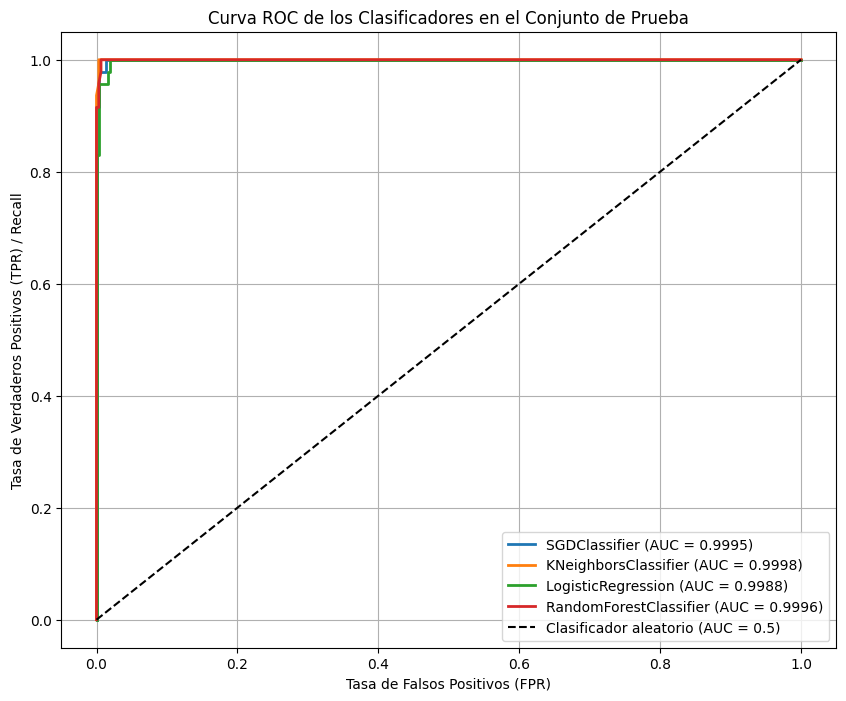

In [3]:
plt.figure(figsize=(10, 8))

for name, metrics in results.items():
    if metrics["y_scores"] is not None:
        fpr, tpr, _ = roc_curve(y_test_5, metrics["y_scores"])
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {metrics['AUC']:.4f})")
    else:
        print(f"Advertencia: No se pudieron obtener scores para {name}, no se graficará la curva ROC.")

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
plt.title('Curva ROC de los Clasificadores en el Conjunto de Prueba')
plt.grid()
plt.legend(loc="lower right")
plt.show()
